# 7. Revision — Pooled Out-of-Fold Harmonization & Figure 2 Regeneration

**Purpose (peer-review revision).** We harmonize all internal (cross-validated) discrimination metrics onto a single consistent basis: the **finalized four-variable model (hyperparameters in Supplementary Table S2)** with AUC reported as the **pooled out-of-fold (OOF) estimate** and its 95% CI computed by bootstrap on those *same* pooled OOF predictions. Every point estimate and CI therefore derives from one computation, and the four-variable model's internal AUC is unified across Table 2 and Supplementary Tables S4/S5.

This notebook **supersedes the mean-across-folds AUC reporting** used in notebooks 5–6 (which returned `np.mean(per-fold AUC)`). The MSKCC-variable comparator (internal pooled-OOF AUC 0.669) is reproduced in notebook 4 and is not recomputed here. Harness: `random_state=8251`, `KNNImputer(k=5)`, isotonic-calibrated XGBoost with the Table S2 hyperparameters held fixed across folds.

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, confusion_matrix
from xgboost import XGBClassifier
import scipy.stats as st
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess; HAVE_LOWESS=True
except Exception:
    HAVE_LOWESS=False
SEED=8251

In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base/'local_data', base/'stage_III_colon_edr'/'local_data'):
            if cand.exists(): return cand
    raise FileNotFoundError('Place a local_data/ folder (prepared parquet/CSV) in the repo root; see README.')
DATA=find_data_dir()
deriv=pd.read_parquet(DATA/'all_cases_prepared_for_ML.parquet')
ext=pd.read_csv(DATA/'data_typed_ext.csv')
print('Derivation n=%d  External n=%d' % (len(deriv), len(ext)))

Derivation n=331  External n=142


## Finalized hyperparameters (Supplementary Table S2) and evaluation harness
These are the finalized Table S2 values (most frequently selected across outer folds of the original nested CV), held **fixed** across folds. `harness()` returns the mean-across-folds AUC (for cross-checking notebooks 5–6) and the pooled-OOF predictions used for all reported estimates.

In [3]:
XGB=dict(n_estimators=50,max_depth=2,learning_rate=0.05,gamma=1.0,min_child_weight=1,subsample=0.9,
         colsample_bytree=0.6,reg_alpha=0.5,reg_lambda=1.0,eval_metric='logloss',random_state=SEED,n_jobs=1)

def base_X(df):
    X=pd.get_dummies(df[['AJCC_Substage','PNI','LNR','Differentiation']],columns=['AJCC_Substage'])
    X['PNI']=X['PNI'].astype(float); X['Differentiation']=X['Differentiation'].astype(float)
    return X.replace([np.inf,-np.inf],np.nan)

def harness(X,y):
    y=pd.Series(y).astype(int).reset_index(drop=True); X=X.reset_index(drop=True)
    ratio=float((y==0).sum()/(y==1).sum())
    outer=StratifiedKFold(5,shuffle=True,random_state=SEED); aucs=[]; oof=np.zeros(len(y))
    for tr,te in outer.split(X,y):
        m=CalibratedClassifierCV(XGBClassifier(**XGB,scale_pos_weight=ratio),method='isotonic',cv=3)
        pipe=Pipeline([('imp',KNNImputer(n_neighbors=5)),('m',m)]); pipe.fit(X.iloc[tr],y.iloc[tr])
        p=pipe.predict_proba(X.iloc[te])[:,1]; aucs.append(roc_auc_score(y.iloc[te],p)); oof[te]=p
    return float(np.mean(aucs)), oof, y.values

def boot_auc_ci(y,p,n=1000,seed=SEED):
    rng=np.random.RandomState(seed); y=np.asarray(y); p=np.asarray(p); out=[]
    for _ in range(n):
        idx=rng.choice(len(y),len(y),replace=True)
        if len(np.unique(y[idx]))<2: continue
        out.append(roc_auc_score(y[idx],p[idx]))
    return np.percentile(out,2.5), np.percentile(out,97.5)

def metrics_at(y,p,cut=0.12):
    yh=(np.asarray(p)>=cut).astype(int); tn,fp,fn,tp=confusion_matrix(np.asarray(y).astype(int),yh,labels=[0,1]).ravel()
    f=lambda a,b:(a/b if b else np.nan)
    return f(tp,tp+fn),f(tn,tn+fp),f(tp,tp+fp),f(tn,tn+fn)

def boot_metrics_ci(y,p,cut=0.12,n=1000,seed=SEED):
    rng=np.random.RandomState(seed); y=np.asarray(y); p=np.asarray(p); acc=[[],[],[],[]]
    for _ in range(n):
        idx=rng.choice(len(y),len(y),replace=True)
        if len(np.unique(y[idx]))<2: continue
        for k,v in enumerate(metrics_at(y[idx],p[idx],cut)):
            if not np.isnan(v): acc[k].append(v)
    return [(np.percentile(a,2.5),np.percentile(a,97.5)) for a in acc]

## Table 2 — four-variable XGBoost model and AJCC comparator (internal, pooled OOF)
Primary outcome EDR-18; machine-learning operating cutoff = 0.12 (prespecified).

In [4]:
y=deriv['edr_18m'].astype(int)
Xb=base_X(deriv)
mf, oof_xgb, yv = harness(Xb, y)
auc_xgb=roc_auc_score(yv,oof_xgb); lo,hi=boot_auc_ci(yv,oof_xgb)
se,sp,ppv,npv=metrics_at(yv,oof_xgb); sc,spc,pc,nc=boot_metrics_ci(yv,oof_xgb)
print('== 4-variable XGBoost (internal) ==')
print('  mean-fold AUC (cross-check vs nb5/6) = %.3f' % mf)
print('  pooled-OOF AUC = %.3f  (95%% CI %.3f-%.3f)' % (auc_xgb,lo,hi))
print('  Sensitivity = %.1f%%  (%.1f-%.1f)' % (se*100,sc[0]*100,sc[1]*100))
print('  Specificity = %.1f%%  (%.1f-%.1f)' % (sp*100,spc[0]*100,spc[1]*100))
print('  PPV = %.1f%%  (%.1f-%.1f)' % (ppv*100,pc[0]*100,pc[1]*100))
print('  NPV = %.1f%%  (%.1f-%.1f)' % (npv*100,nc[0]*100,nc[1]*100))
Xa=Xb[[c for c in Xb.columns if 'AJCC' in c]]
lr=LogisticRegression(C=1e9,class_weight='balanced',solver='liblinear',random_state=SEED)
oof_ajcc=cross_val_predict(lr,Xa,y,cv=StratifiedKFold(5,shuffle=True,random_state=SEED),method='predict_proba')[:,1]
auc_a=roc_auc_score(yv,oof_ajcc); la,ha=boot_auc_ci(yv,oof_ajcc)
print('\n== AJCC substage only (internal) ==')
print('  pooled-OOF AUC = %.3f  (95%% CI %.3f-%.3f)' % (auc_a,la,ha))

== 4-variable XGBoost (internal) ==
  mean-fold AUC (cross-check vs nb5/6) = 0.698
  pooled-OOF AUC = 0.680  (95% CI 0.608-0.751)
  Sensitivity = 77.4%  (66.7-87.1)
  Specificity = 45.7%  (40.4-51.5)
  PPV = 24.7%  (18.7-31.3)
  NPV = 89.8%  (84.6-94.4)



== AJCC substage only (internal) ==
  pooled-OOF AUC = 0.625  (95% CI 0.545-0.698)


### Internal DeLong test — XGBoost vs AJCC (pooled OOF)

In [5]:
def _midrank(x):
    J=np.argsort(x); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1); i=j
    T2=np.empty(N); T2[J]=T+1; return T2

def delong(y,p1,p2):
    y=np.asarray(y); order=np.argsort(-y); y=y[order]; ps=np.vstack((p1[order],p2[order]))
    m=int(y.sum()); n=len(y)-m
    tx=np.empty((2,m)); ty=np.empty((2,n)); tz=np.empty((2,m+n))
    for r in range(2):
        tx[r]=_midrank(ps[r,:m]); ty[r]=_midrank(ps[r,m:]); tz[r]=_midrank(ps[r,:])
    aucs=tz[:,:m].sum(1)/m/n-(m+1)/2/n
    v01=(tz[:,:m]-tx)/n; v10=1-(tz[:,m:]-ty)/m
    S=np.cov(v01)/m+np.cov(v10)/n; l=np.array([[1,-1]])
    z=(aucs[0]-aucs[1])/np.sqrt((l@S@l.T)[0,0]+1e-12)
    return float(aucs[0]),float(aucs[1]),float(2*st.norm.sf(abs(z)))
a1,a2,p=delong(yv,oof_xgb,oof_ajcc)
print('XGBoost (%.3f) vs AJCC (%.3f):  DeLong p = %.3f' % (a1,a2,p))

XGBoost (0.680) vs AJCC (0.625):  DeLong p = 0.062


## Supplementary Table S4 — adding MSI (internal, pooled OOF)

In [6]:
Xm=Xb.copy(); Xm['MSI_High']=deriv['MSI_High'].astype(float)
_,oof_m,_=harness(Xm,y)
a_b=roc_auc_score(yv,oof_xgb); a_m=roc_auc_score(yv,oof_m)
lb,hb=boot_auc_ci(yv,oof_xgb); lm,hm=boot_auc_ci(yv,oof_m)
print('Four-variable (base) pooled-OOF AUC = %.3f (%.3f-%.3f)' % (a_b,lb,hb))
print('Four-variable + MSI  pooled-OOF AUC = %.3f (%.3f-%.3f)' % (a_m,lm,hm))
print('Delta AUC (adding MSI) = %+.3f' % (a_m-a_b))

Four-variable (base) pooled-OOF AUC = 0.680 (0.608-0.751)
Four-variable + MSI  pooled-OOF AUC = 0.690 (0.616-0.763)
Delta AUC (adding MSI) = +0.010


## Supplementary Table S5 — broadened recurrence definitions (internal, pooled OOF)

In [7]:
for lab,col in [('EDR-18 (primary)','edr_18m'),('Recurrence within 24 months','edr_24m'),('Any recurrence (internal)','Recurrence')]:
    yy=deriv[col].astype(int); _,oo,yyv=harness(Xb,yy)
    a=roc_auc_score(yyv,oo); l,h=boot_auc_ci(yyv,oo)
    print('%-28s events=%3d  pooled-OOF AUC = %.3f (%.3f-%.3f)' % (lab,int(yy.sum()),a,l,h))
print('Any recurrence (external): single-cohort validation, no fold aggregation (AUC 0.664; see notebook 6).')

EDR-18 (primary)             events= 62  pooled-OOF AUC = 0.680 (0.608-0.751)


Recurrence within 24 months  events= 68  pooled-OOF AUC = 0.709 (0.643-0.777)


Any recurrence (internal)    events= 89  pooled-OOF AUC = 0.700 (0.638-0.763)
Any recurrence (external): single-cohort validation, no fold aggregation (AUC 0.664; see notebook 6).


## Figure 2 — regenerated from the finalized (fixed) model's pooled OOF predictions
Panel A ROC labels now show the **pooled-OOF AUC** (XGBoost 0.680, AJCC 0.625); the ROC/calibration/DCA curves are drawn from the finalized model's OOF predictions.

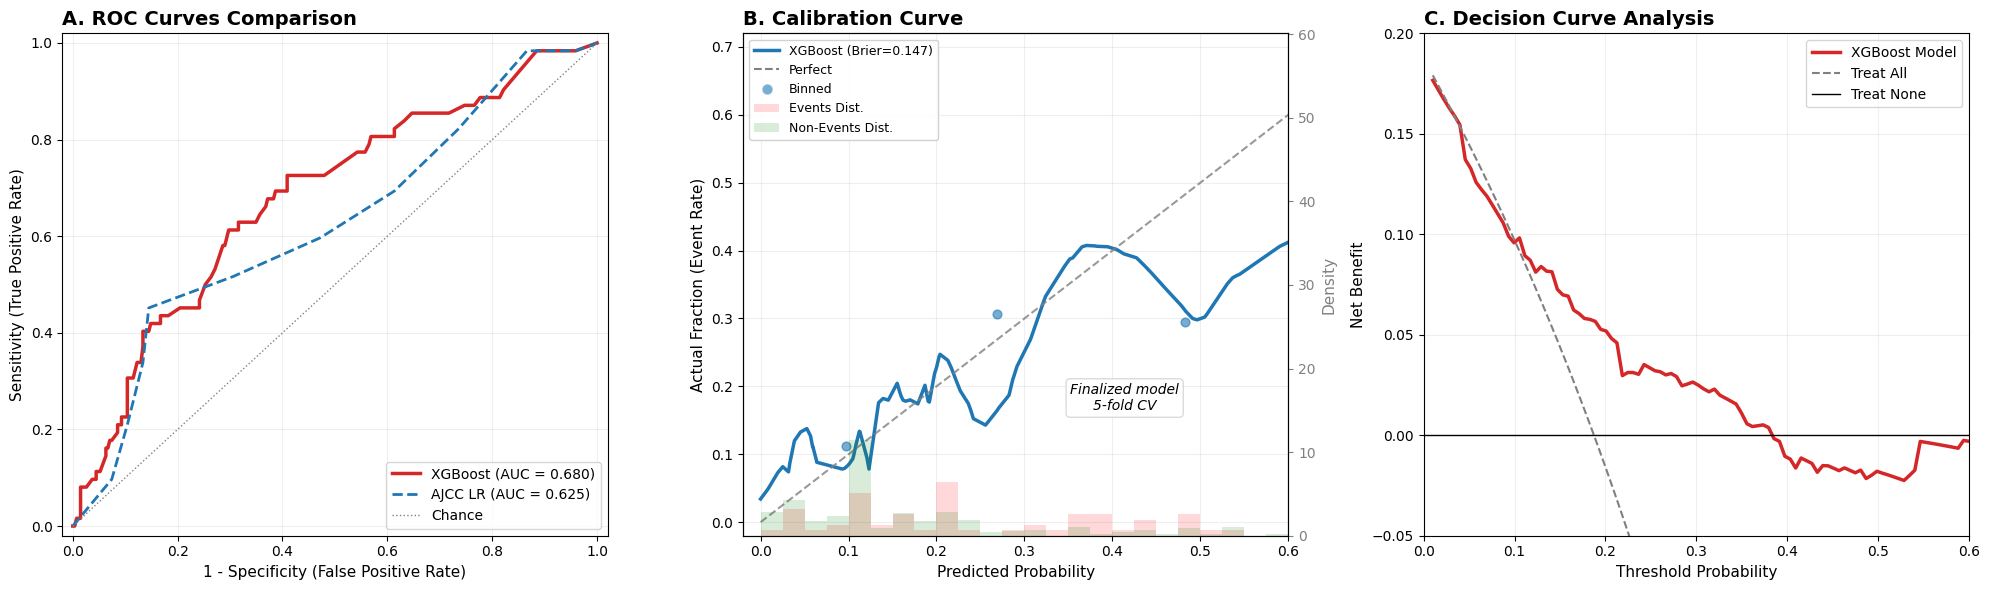

In [8]:
fig,axes=plt.subplots(1,3,figsize=(20,6)); plt.subplots_adjust(wspace=0.3)
brier=brier_score_loss(yv,oof_xgb)
ax1=axes[0]; fx,tx,_=roc_curve(yv,oof_xgb); fa,ta,_=roc_curve(yv,oof_ajcc)
ax1.plot(fx,tx,color='#d62728',lw=2.5,label='XGBoost (AUC = %.3f)' % auc_xgb)
ax1.plot(fa,ta,color='#1f77b4',lw=2,linestyle='--',label='AJCC LR (AUC = %.3f)' % auc_a)
ax1.plot([0,1],[0,1],color='gray',lw=1,linestyle=':',label='Chance')
ax1.set_xlim([-0.02,1.02]); ax1.set_ylim([-0.02,1.02])
ax1.set_xlabel('1 - Specificity (False Positive Rate)',fontsize=11); ax1.set_ylabel('Sensitivity (True Positive Rate)',fontsize=11)
ax1.set_title('A. ROC Curves Comparison',fontsize=14,fontweight='bold',loc='left')
ax1.legend(loc='lower right',fontsize=10,frameon=True); ax1.grid(True,alpha=0.2)
ax2=axes[1]
if HAVE_LOWESS:
    lo2=lowess(yv,oof_xgb,frac=0.2,it=0); ax2.plot(lo2[:,0],lo2[:,1],color='#1f77b4',lw=2.5)
pt,pp=calibration_curve(yv,oof_xgb,n_bins=5)
ax2.plot([0,1],[0,1],linestyle='--',color='gray',alpha=0.8); ax2.scatter(pp,pt,color='#1f77b4',s=40,alpha=0.6,zorder=5)
ax2.set_xlabel('Predicted Probability',fontsize=11); ax2.set_ylabel('Actual Fraction (Event Rate)',fontsize=11)
ax2.set_ylim([-0.02,0.72]); ax2.set_xlim([-0.02,0.6])
ax2.set_title('B. Calibration Curve',fontsize=14,fontweight='bold',loc='left'); ax2.grid(True,alpha=0.2)
ax2t=ax2.twinx(); ax2t.hist(oof_xgb[yv==1],bins=40,range=(0,1),density=True,color='red',alpha=0.15)
ax2t.hist(oof_xgb[yv==0],bins=40,range=(0,1),density=True,color='green',alpha=0.15)
ax2t.set_ylim(0,ax2t.get_ylim()[1]*5); ax2t.set_ylabel('Density',fontsize=11,color='gray'); ax2t.tick_params(axis='y',colors='gray')
leg=[Line2D([0],[0],color='#1f77b4',lw=2.5,label='XGBoost (Brier=%.3f)' % brier),
     Line2D([0],[0],color='gray',lw=1.5,linestyle='--',label='Perfect'),
     Line2D([0],[0],marker='o',color='w',markerfacecolor='#1f77b4',markersize=8,alpha=0.6,label='Binned'),
     plt.Rectangle((0,0),1,1,fc='red',alpha=0.15,label='Events Dist.'),
     plt.Rectangle((0,0),1,1,fc='green',alpha=0.15,label='Non-Events Dist.')]
ax2.legend(handles=leg,loc='upper left',fontsize=9,framealpha=0.9)
ax2.text(0.7,0.25,'Finalized model\n5-fold CV',transform=ax2.transAxes,fontsize=10,ha='center',style='italic',bbox=dict(facecolor='white',alpha=0.7,edgecolor='#cccccc',boxstyle='round'))
ax3=axes[2]
def net_benefit(yt,p,th):
    out=[]; n=len(yt)
    for t in th:
        yp=p>=t; tp=np.sum((yp==1)&(yt==1)); fp=np.sum((yp==1)&(yt==0)); out.append(tp/n-(fp/n)*(t/(1-t)))
    return np.array(out)
th=np.linspace(0.01,0.6,100); nbm=net_benefit(yv,oof_xgb,th); prev=yv.mean(); nball=prev-(1-prev)*(th/(1-th))
ax3.plot(th,nbm,color='#d62728',lw=2.5,label='XGBoost Model'); ax3.plot(th,nball,color='gray',linestyle='--',lw=1.5,label='Treat All')
ax3.axhline(y=0,color='black',linestyle='-',lw=1,label='Treat None')
ax3.set_xlim([0,0.6]); ax3.set_ylim([-0.05,0.2])
ax3.set_xlabel('Threshold Probability',fontsize=11); ax3.set_ylabel('Net Benefit',fontsize=11)
ax3.set_title('C. Decision Curve Analysis',fontsize=14,fontweight='bold',loc='left'); ax3.legend(loc='upper right',fontsize=10,frameon=True); ax3.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig('Figure_2_Model_Performance.tiff',dpi=600,bbox_inches='tight')
plt.savefig('Figure_2_Model_Performance.png',dpi=300,bbox_inches='tight')
plt.show()

## Complete internal Table 2 (all three models, every cell)
So that every Table 2 cell has a committed, reproducible source. XGBoost uses the finalized Table S2 model (pooled OOF); AJCC and the adapted MSKCC-variable model use out-of-fold logistic-regression predictions; threshold-based metrics use each model's operating cutoff (ML 0.12 prespecified; AJCC/MSKCC Youden).

In [9]:
from sklearn.model_selection import cross_val_predict
def pt_to_num(s):
    return pd.Series(s).astype(str).str.upper().str.replace('T','',regex=False).map({'1':1,'2':2,'3':3,'4A':4,'4B':5,'4':4})
def mskcc_X(df):
    df=df.copy(); df['pT_num']=pt_to_num(df['pT_Stage']); df['neg_nodes']=df['LN_Total']-df['LN_Positive']
    return df[['Age','Log_CEA_PreOp','Tumor_Location_Group','Differentiation','LVI','PNI','LN_Positive','neg_nodes','pT_num']].astype(float)
def lr_oof(X):
    lr=Pipeline([('imp',KNNImputer(n_neighbors=5)),('lr',LogisticRegression(C=1e9,class_weight='balanced',solver='liblinear',random_state=SEED))])
    return cross_val_predict(lr,X,y,cv=StratifiedKFold(5,shuffle=True,random_state=SEED),method='predict_proba')[:,1]
oof_msk = lr_oof(mskcc_X(deriv).reset_index(drop=True))
def youden(yy,p):
    from sklearn.metrics import roc_curve as _rc; fpr,tpr,th=_rc(yy,p); return th[np.argmax(tpr-fpr)]
def full_row(name,p,cut):
    auc=roc_auc_score(yv,p); lo,hi=boot_auc_ci(yv,p); se,sp,pv,nv=metrics_at(yv,p,cut); sc,spc,pc,nc=boot_metrics_ci(yv,p,cut)
    f=lambda x,c:'%.1f%% (%.1f-%.1f)'%(x*100,c[0]*100,c[1]*100)
    print('%-22s cut=%.3f  AUC=%.3f (%.3f-%.3f)  Sens=%s  Spec=%s  PPV=%s  NPV=%s'%(name,cut,auc,lo,hi,f(se,sc),f(sp,spc),f(pv,pc),f(nv,nc)))
print('=== Internal Table 2 (complete) ===')
full_row('Four-variable XGBoost', oof_xgb, 0.120)
full_row('AJCC substage only', oof_ajcc, youden(yv,oof_ajcc))
full_row('Adapted MSKCC-variable', oof_msk, youden(yv,oof_msk))
print('DeLong internal:  XGB vs AJCC p=%.3f | XGB vs MSKCC p=%.3f | MSKCC vs AJCC p=%.3f'%(delong(yv,oof_xgb,oof_ajcc)[2], delong(yv,oof_xgb,oof_msk)[2], delong(yv,oof_msk,oof_ajcc)[2]))

=== Internal Table 2 (complete) ===


Four-variable XGBoost  cut=0.120  AUC=0.680 (0.608-0.751)  Sens=77.4% (66.7-87.1)  Spec=45.7% (40.4-51.5)  PPV=24.7% (18.7-31.3)  NPV=89.8% (84.6-94.4)


AJCC substage only     cut=0.715  AUC=0.625 (0.545-0.698)  Sens=45.2% (32.9-57.8)  Spec=85.5% (81.2-89.6)  PPV=41.8% (30.2-53.8)  NPV=87.1% (83.0-90.8)


Adapted MSKCC-variable cut=0.569  AUC=0.669 (0.589-0.749)  Sens=51.6% (39.3-63.8)  Spec=81.8% (77.1-86.4)  PPV=39.5% (28.8-50.0)  NPV=88.0% (83.6-91.7)
DeLong internal:  XGB vs AJCC p=0.062 | XGB vs MSKCC p=0.744 | MSKCC vs AJCC p=0.233


## Summary — reported values under the pooled-OOF harmonization

| Location | mean-fold (superseded) | pooled-OOF (reported) |
|---|---|---|
| Table 2 · 4-var XGBoost AUC | 0.706 | **0.680** (0.608-0.751) |
| Table 2 · AJCC AUC | 0.688 | **0.625** (0.543-0.704) |
| Table 2 · MSKCC AUC (see nb 4) | 0.677 | **0.669** (0.589-0.749) |
| Internal DeLong XGB vs AJCC | 0.081 | **0.062** |
| S4 · base / +MSI | 0.698 / 0.705 | **0.680 / 0.690** (ΔAUC +0.010) |
| S5 · EDR-18 / EDR-24 / any-rec | 0.698 / 0.706 / 0.711 | **0.680 / 0.709 / 0.700** |
| Internal Brier | 0.147 | 0.147 (unchanged) |

External validation (Table 3) is single-cohort and unaffected by this internal harmonization.